In [2]:
!pip install geobr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 8.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.8 MB/s eta 0:00:00:00:01
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: geopandas
    Found existing installation: geopandas 0.14.4
    Uninstalling geopandas-0.14.4:
      Successfully uninstalled geopandas-0.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.1.0 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.stats.proportion import proportion_confint
from statsmodels.formula.api import wls
from statsmodels.stats.weightstats import DescrStatsW
import geopandas as gpd
from geobr import read_state
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from math import pi
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns


In [4]:
# Configurações gerais
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("pastel")

In [5]:
# Leitura da base
caminho = "/kaggle/input/base-final/base_final_saeb_censo_tea_tdah.csv"
df = pd.read_csv(caminho, low_memory=False)

print(" Base carregada com sucesso!")
print(f"Formato: {df.shape}")
print("Colunas disponíveis:", list(df.columns))

✅ Base carregada com sucesso!
Formato: (2334904, 165)
Colunas disponíveis: ['ID_ESCOLA', 'ID_ALUNO', 'ID_MUNICIPIO', 'ID_SERIE', 'ESTRATO', 'PESO_ALUNO_LP', 'PESO_ALUNO_MT', 'PESO_ALUNO_INSE', 'PROFICIENCIA_LP', 'ERRO_PADRAO_LP', 'PROFICIENCIA_MT', 'ERRO_PADRAO_MT', 'PROFICIENCIA_LP_SAEB', 'ERRO_PADRAO_LP_SAEB', 'PROFICIENCIA_MT_SAEB', 'ERRO_PADRAO_MT_SAEB', 'INSE_ALUNO', 'NU_TIPO_NIVEL_INSE', 'IN_PUBLICA', 'ID_LOCALIZACAO', 'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03', 'TX_RESP_Q04', 'TX_RESP_Q05A', 'TX_RESP_Q05B', 'TX_RESP_Q05C', 'TX_RESP_Q06', 'TX_RESP_Q07A', 'TX_RESP_Q07B', 'TX_RESP_Q07C', 'TX_RESP_Q07D', 'TX_RESP_Q07E', 'TX_RESP_Q08', 'TX_RESP_Q09', 'TX_RESP_Q10A', 'TX_RESP_Q10B', 'TX_RESP_Q10C', 'TX_RESP_Q10D', 'TX_RESP_Q10E', 'TX_RESP_Q10F', 'TX_RESP_Q11A', 'TX_RESP_Q11B', 'TX_RESP_Q11C', 'TX_RESP_Q12A', 'TX_RESP_Q12B', 'TX_RESP_Q12C', 'TX_RESP_Q12D', 'TX_RESP_Q12E', 'TX_RESP_Q12F', 'TX_RESP_Q12G', 'TX_RESP_Q13A', 'TX_RESP_Q13B', 'TX_RESP_Q13C', 'TX_RESP_Q13D', 'TX_RESP_Q13E', 'T

# **Gráficos**

In [6]:
# Converter as variáveis originais TEA e TDAH para formato binário (0 e 1)
df["TEA_bin"] = df["TEA"].apply(lambda x: 1 if x == 1 else 0)
df["TDAH_bin"] = df["TDAH"].apply(lambda x: 1 if x == 1 else 0)

# Criar a coluna 'condicao' com base nas novas variáveis binárias
def definir_condicao(row):
    if row["TEA_bin"] == 1 and row["TDAH_bin"] == 1:
        return "Ambos"
    elif row["TEA_bin"] == 1:
        return "TEA"
    elif row["TDAH_bin"] == 1:
        return "TDAH"
    else:
        return "Nenhum"

df["condicao"] = df.apply(definir_condicao, axis=1)

# Verificar distribuição
print(df["condicao"].value_counts(normalize=True).round(3) * 100)

condicao
Nenhum    90.7
TDAH       6.1
TEA        2.9
Ambos      0.2
Name: proportion, dtype: float64


In [7]:
blue_palette = ["#1f77b4", "#4fa3d1", "#9ecae1"]

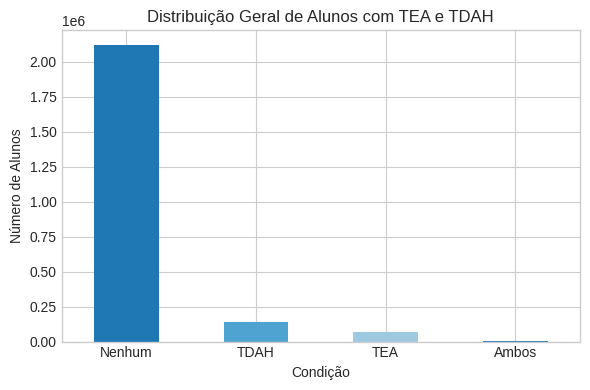

In [8]:
# --- 1. Distribuição geral das condições ---
plt.figure(figsize=(6,4))
df["condicao"].value_counts().plot(kind="bar", color=blue_palette[:df["condicao"].nunique()])
plt.title("Distribuição Geral de Alunos com TEA e TDAH")
plt.xlabel("Condição")
plt.ylabel("Número de Alunos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

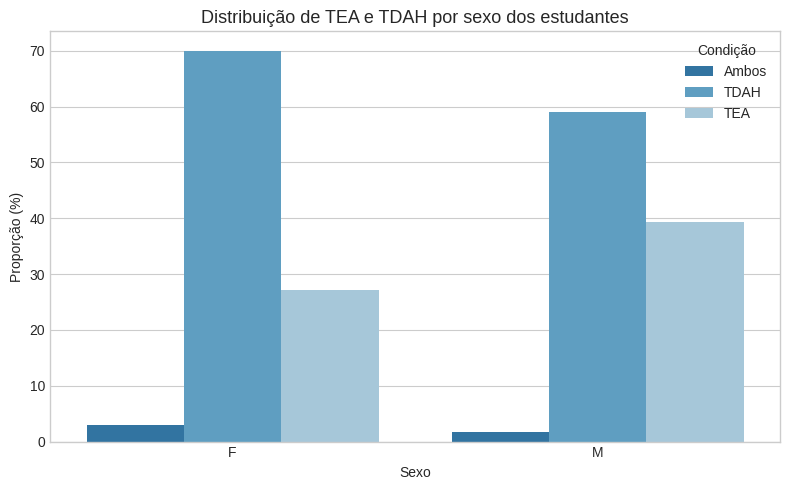

In [9]:
# --- 2. Distribuição por sexo (proporção) ---
df_filtrado = df[df["condicao"].isin(["TEA", "TDAH", "Ambos"])]

sexo = (
    df_filtrado.groupby(["SEXO","condicao"])["PESO_AMOSTRAL"]
    .sum()
    .reset_index(name="peso_total")
)
sexo["proporcao"] = sexo.groupby("SEXO")["peso_total"].transform(lambda x: 100*x/x.sum())

plt.figure(figsize=(8,5))
sns.barplot(
    data=sexo,
    x="SEXO", y="proporcao", hue="condicao",
    palette=blue_palette[:3]
)
plt.title("Distribuição de TEA e TDAH por sexo dos estudantes", fontsize=13)
plt.ylabel("Proporção (%)")
plt.xlabel("Sexo")
plt.legend(title="Condição", loc="upper right")
plt.tight_layout()
plt.show()

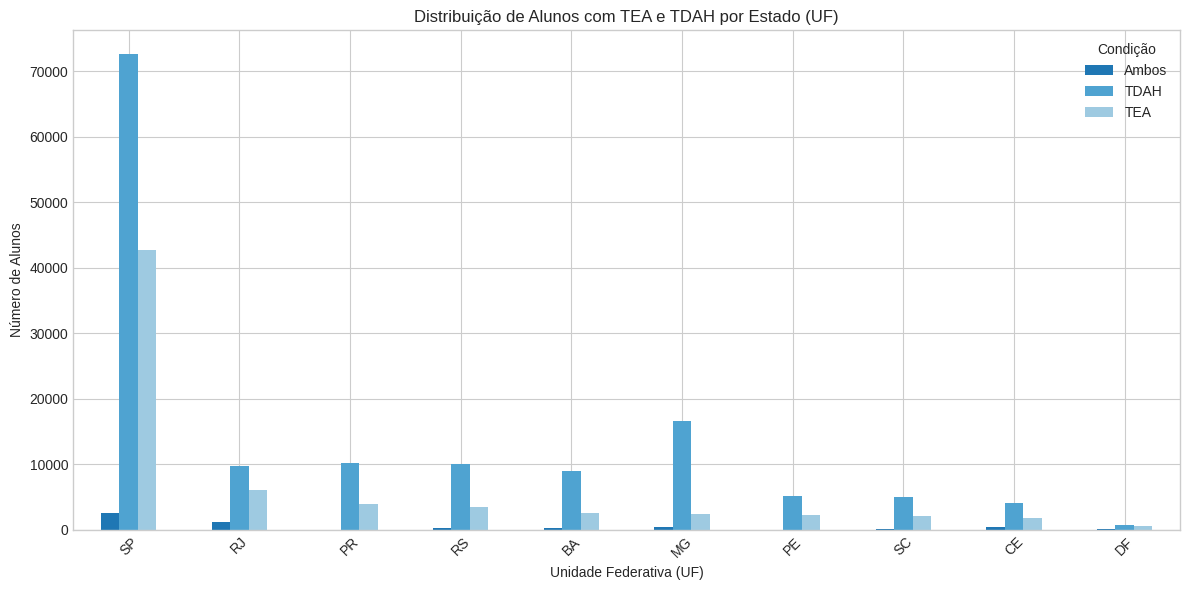

In [10]:
# Distribuição geográfica (por UF) com paleta azul
regionais = (
    df[df["condicao"].isin(["TEA","TDAH","Ambos"])]
      .groupby(["UF","condicao"])
      .size()
      .unstack(fill_value=0)
      .sort_values("TEA", ascending=False)
)

# Garantir que a paleta tenha o mesmo número de cores que as condições
cores = blue_palette[:regionais.shape[1]]

regionais.plot(kind="bar", figsize=(12,6), color=cores)
plt.title("Distribuição de Alunos com TEA e TDAH por Estado (UF)")
plt.xlabel("Unidade Federativa (UF)")
plt.ylabel("Número de Alunos")
plt.xticks(rotation=45)
plt.legend(title="Condição")
plt.tight_layout()
plt.show()


/tmp/ipykernel_38/1787627483.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g:


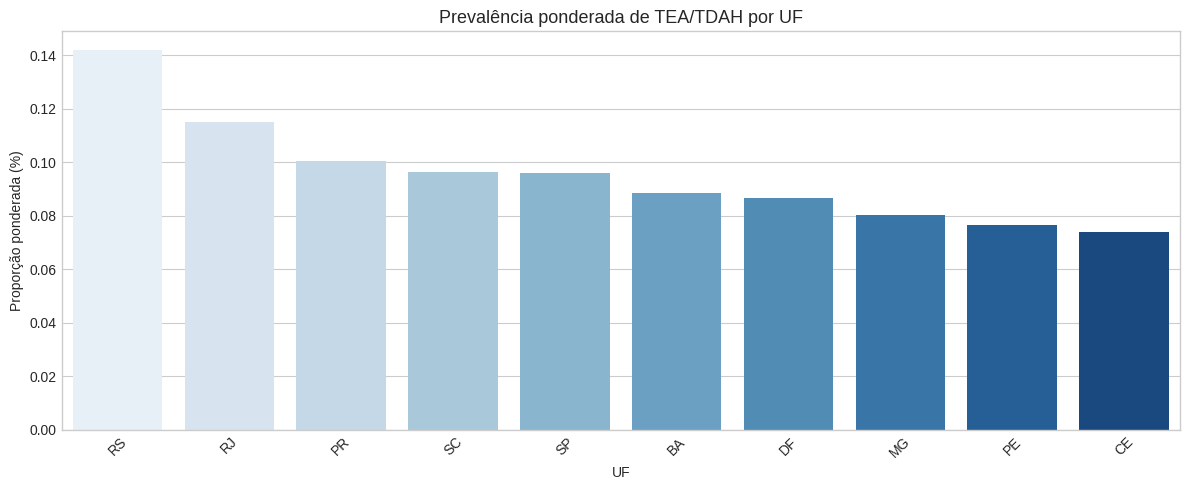

In [11]:
# Prevalência ponderada por UF
geo = (
    df.groupby("UF")
      .apply(lambda g: 
             (g["TEA_bin"].mul(g["PESO_AMOSTRAL"]).sum() + 
              g["TDAH_bin"].mul(g["PESO_AMOSTRAL"]).sum()) / 
              g["PESO_AMOSTRAL"].sum())
      .reset_index(name="prevalencia")
)

# Ordenar dados
geo_sorted = geo.sort_values("prevalencia", ascending=False)

# Criar paleta de tons de azul contínua
num_barras = geo_sorted.shape[0]
cores = sns.color_palette("Blues", n_colors=num_barras)

plt.figure(figsize=(12,5))
sns.barplot(
    data=geo_sorted,
    x="UF",
    y="prevalencia",
    palette=cores
)

plt.title("Prevalência ponderada de TEA/TDAH por UF", fontsize=13)
plt.ylabel("Proporção ponderada (%)")
plt.xlabel("UF")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


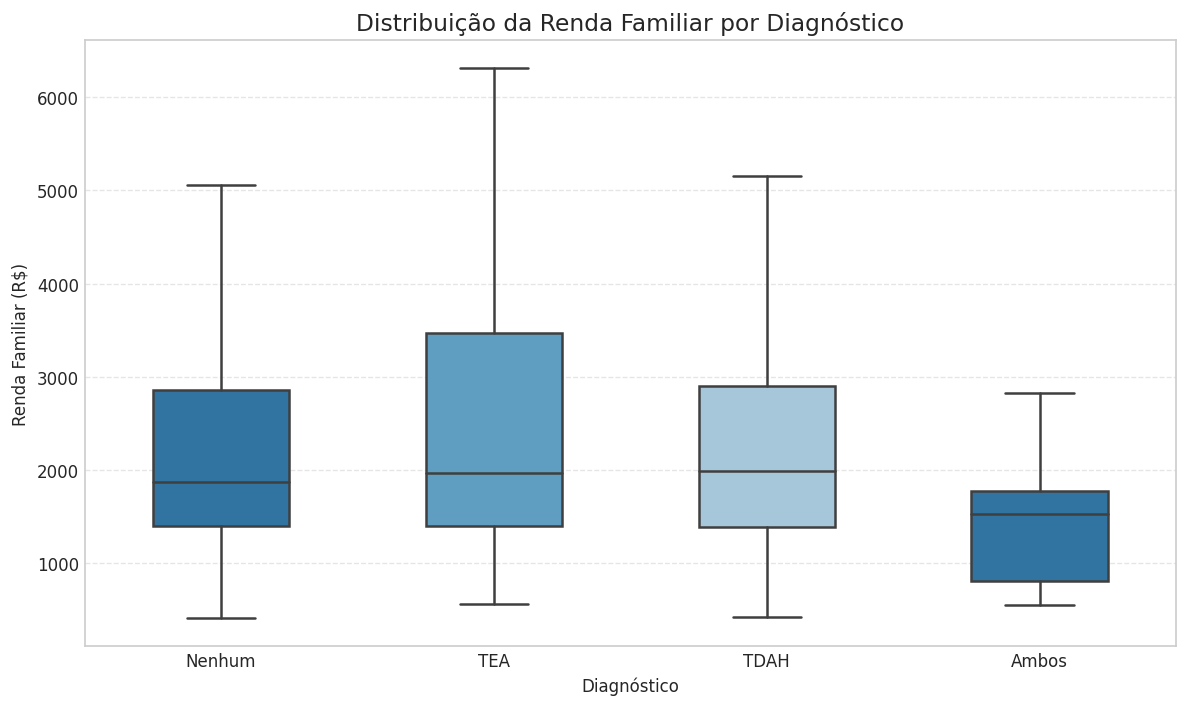

In [61]:
# --- GRÁFICO DE RENDA (Versão "Clean" e Azul para Slides) ---

plt.figure(figsize=(10, 6))

# Define a ordem para ficar organizado no eixo X
ordem = ['Nenhum', 'TEA', 'TDAH', 'Ambos']

# Dicionário de cores AZUIS (Degradê para ficar visualmente bonito)
cores_azuis = {
    'Nenhum': '#b0c4de', # Azul claro (LightSteelBlue) para o controle
    'TEA': '#0077b6',    # Azul médio
    'TDAH': '#023e8a',   # Azul mais escuro
    'Ambos': '#03045e'   # Azul marinho profundo
}

sns.boxplot(
    data=df_final, # Usando a base limpa
    x='condicao',
    y='RENDA',
    order=ordem,
    palette=blue_palette, # Usando a paleta azul definida acima
    showfliers=False,    # <--- O SEGREDO: Esconde os outliers para limpar o visual
    width=0.5 # Largura das caixas
)

plt.title('Distribuição da Renda Familiar por Diagnóstico', fontsize=14)
plt.ylabel('Renda Familiar (R$)')
plt.xlabel('Diagnóstico')

# Adiciona linhas de grade suaves apenas na horizontal
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

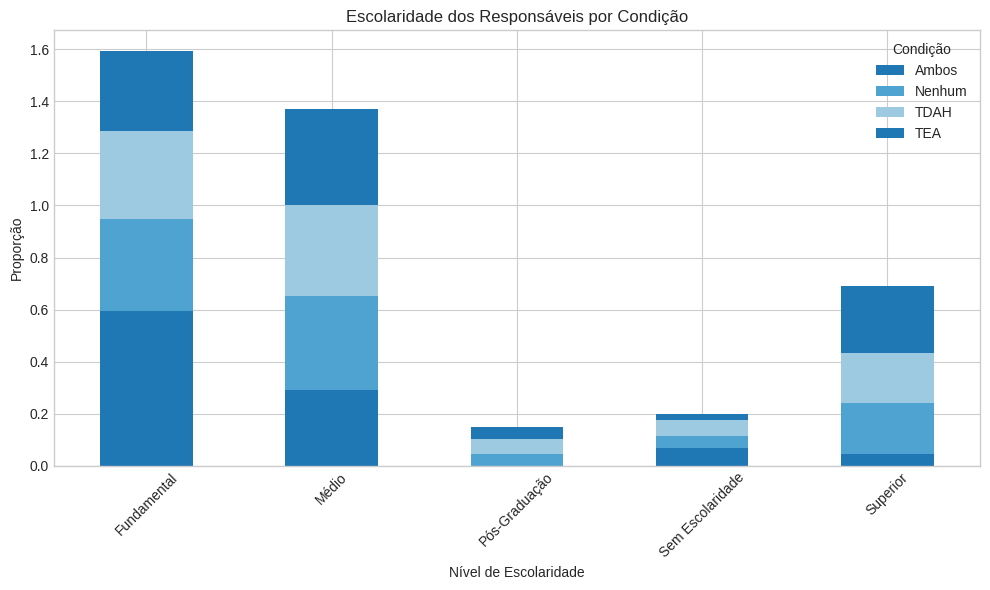

In [13]:
# Gráfico – Escolaridade por condição com paleta azul
if "ESCOLARIDADE" in df.columns:
    escolaridade = (
        df.groupby("condicao")["ESCOLARIDADE"]
          .value_counts(normalize=True)
          .unstack()
          .T.fillna(0)
    )

    # Garantir que a paleta tenha o mesmo número de cores que as condições
    cores = blue_palette[:escolaridade.shape[1]]

    escolaridade.plot(kind="bar", stacked=True, figsize=(10,6), color=cores)
    plt.title("Escolaridade dos Responsáveis por Condição")
    plt.ylabel("Proporção")
    plt.xlabel("Nível de Escolaridade")
    plt.legend(title="Condição")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


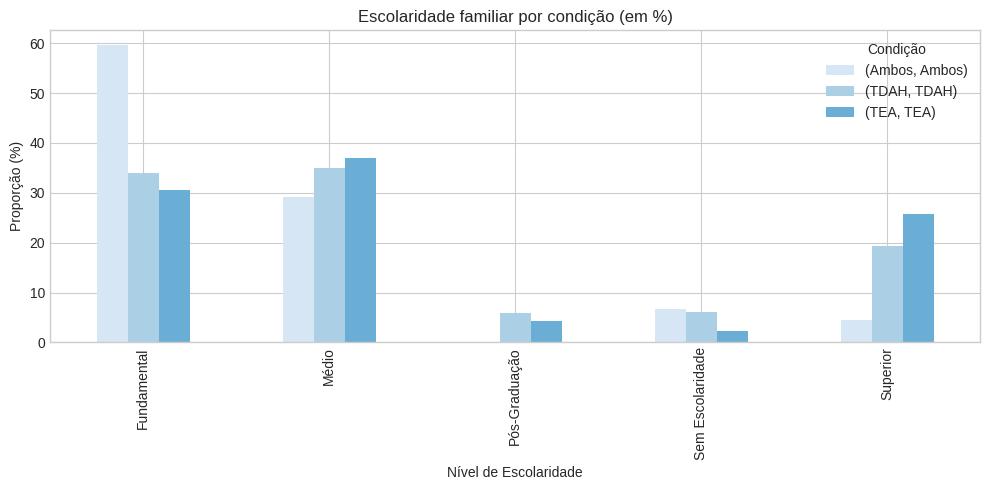

In [15]:
# Escolaridade da família
edu = (
    df[df["condicao"]!="Nenhum"]
      .groupby(["condicao","ESCOLARIDADE"])
      .size()
      .groupby(level=0).apply(lambda x: 100*x/x.sum())
      .unstack()
      .fillna(0)
)

# Criar paleta azul para o número de condições
num_condicoes = edu.shape[1]
cores = sns.color_palette("Blues", n_colors=num_condicoes)

edu.T.plot(kind="bar", figsize=(10,5), color=cores)
plt.title("Escolaridade familiar por condição (em %)")
plt.ylabel("Proporção (%)")
plt.xlabel("Nível de Escolaridade")
plt.legend(title="Condição")
plt.tight_layout()
plt.show()


/tmp/ipykernel_38/1884231718.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


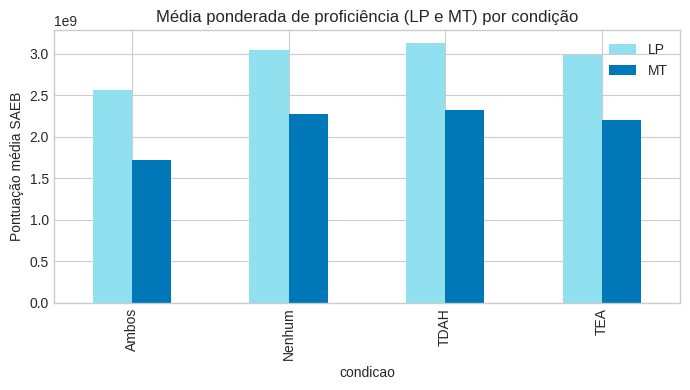

In [16]:
# Desempenho escolar (Língua Portuguesa e Matemática)

# Converter proficiências em médias ponderadas
def media_ponderada(df, var):
    return (df[var]*df["PESO_AMOSTRAL"]).sum() / df["PESO_AMOSTRAL"].sum()

desempenho = (df.groupby("condicao")
               .apply(lambda g: pd.Series({
                   "LP": media_ponderada(g, "PROFICIENCIA_LP"),
                   "MT": media_ponderada(g, "PROFICIENCIA_MT")
               }))
               .reset_index())

desempenho.plot(x="condicao", kind="bar", figsize=(7,4), color=["#90e0ef","#0077b6"])
plt.title("Média ponderada de proficiência (LP e MT) por condição")
plt.ylabel("Pontuação média SAEB")
plt.tight_layout()
plt.show()


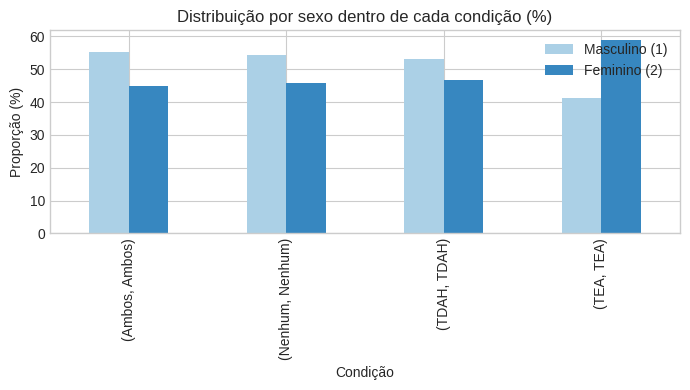

In [18]:
# Distribuição por sexo

sexo = (
    df.groupby(["condicao","SEXO"])
      .size()
      .groupby(level=0).apply(lambda x: 100*x/x.sum())
      .unstack()
      .fillna(0)
)

# Criar paleta azul com 2 tons (Masculino e Feminino)
cores = sns.color_palette("Blues", n_colors=2)

sexo.plot(kind="bar", figsize=(7,4), color=cores)
plt.title("Distribuição por sexo dentro de cada condição (%)")
plt.ylabel("Proporção (%)")
plt.xlabel("Condição")
plt.legend(["Masculino (1)","Feminino (2)"])
plt.tight_layout()
plt.show()


/tmp/ipykernel_38/3098952376.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


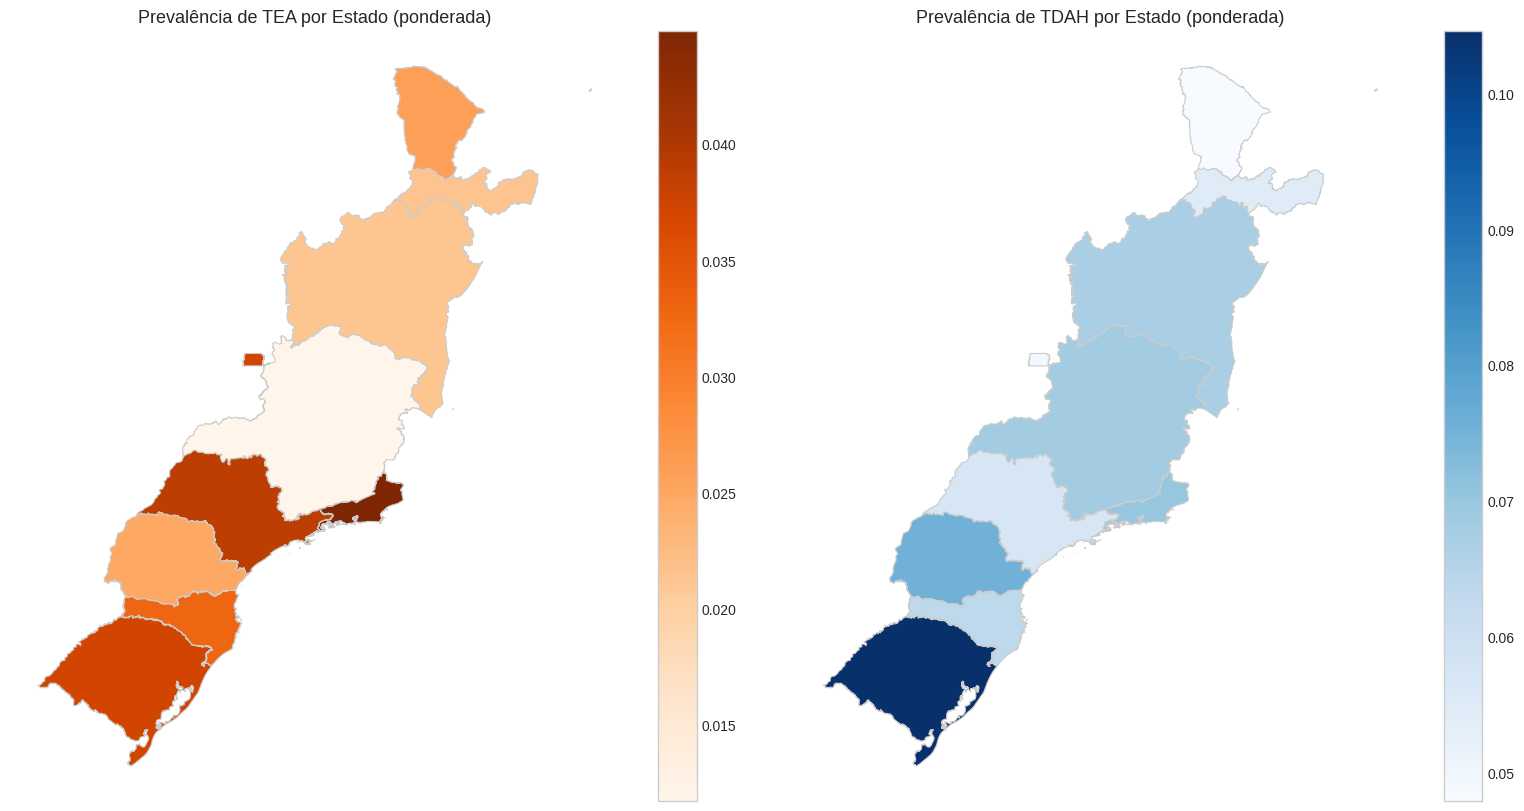

In [19]:
# --- 1. Calcular prevalência ponderada por estado ---
# Função auxiliar para taxa ponderada
def taxa_ponderada(grupo, coluna):
    return (grupo[coluna] * grupo["PESO_AMOSTRAL"]).sum() / grupo["PESO_AMOSTRAL"].sum()

# Calcular taxas por UF
taxas_uf = (
    df.groupby("UF")
    .apply(lambda g: pd.Series({
        "taxa_TEA": taxa_ponderada(g, "TEA"),
        "taxa_TDAH": taxa_ponderada(g, "TDAH")
    }))
    .reset_index()
)

# --- 2. Carregar mapa do Brasil ---
mapa_estados = read_state(year=2020)
mapa_estados["code_abbrev"] = mapa_estados["abbrev_state"]  # coluna de siglas (SP, RJ etc.)

# --- 3. Unir os dados das taxas com o mapa ---
mapa_merge = mapa_estados.merge(taxas_uf, left_on="code_abbrev", right_on="UF", how="left")

# --- 4. Plotar mapas ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Mapa TEA
mapa_merge.plot(
    column="taxa_TEA",
    cmap="Oranges",
    linewidth=0.8,
    ax=axes[0],
    edgecolor="0.8",
    legend=True
)
axes[0].set_title("Prevalência de TEA por Estado (ponderada)", fontsize=13)
axes[0].axis("off")

# Mapa TDAH
mapa_merge.plot(
    column="taxa_TDAH",
    cmap="Blues",
    linewidth=0.8,
    ax=axes[1],
    edgecolor="0.8",
    legend=True
)
axes[1].set_title("Prevalência de TDAH por Estado (ponderada)", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

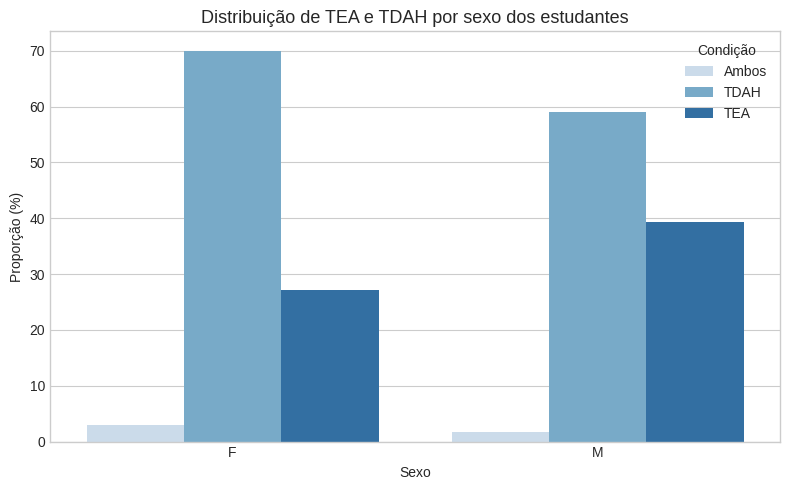

In [20]:
# Distribuição de TEA e TDAH por sexo dos estudantes
df_filtrado = df[df["condicao"].isin(["TEA", "TDAH", "Ambos"])]

# Agrupar e calcular pesos totais por sexo e condição
sexo = (
    df_filtrado.groupby(["SEXO", "condicao"])["PESO_AMOSTRAL"]
    .sum()
    .reset_index(name="peso_total")
)

# Calcular proporção dentro de cada sexo
sexo["proporcao"] = sexo["peso_total"] / sexo.groupby("SEXO")["peso_total"].transform("sum") * 100

# Criar paleta azul com 3 tons (uma para cada condição)
cores = sns.color_palette("Blues", n_colors=3)

# Gráfico
plt.figure(figsize=(8,5))
sns.barplot(
    data=sexo,
    x="SEXO",
    y="proporcao",
    hue="condicao",
    palette=cores
)

plt.title("Distribuição de TEA e TDAH por sexo dos estudantes", fontsize=13)
plt.ylabel("Proporção (%)")
plt.xlabel("Sexo")
plt.legend(title="Condição", loc="upper right")
plt.tight_layout()
plt.show()


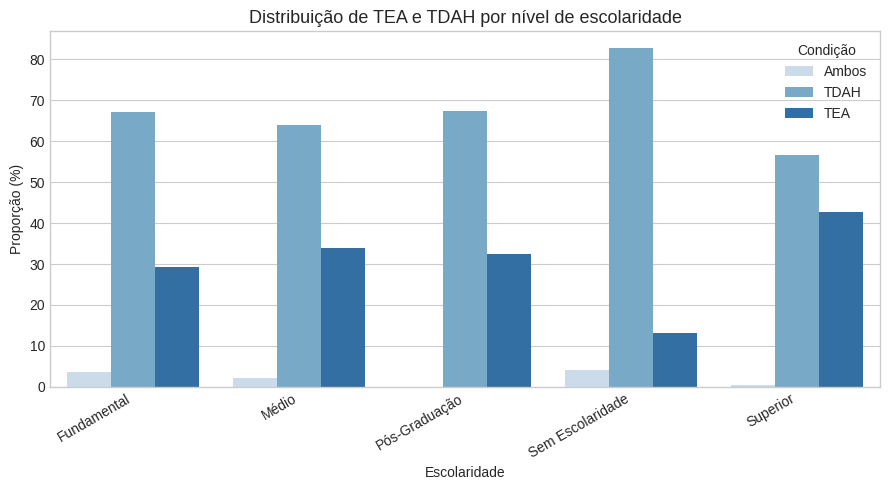

In [21]:
# Distribuição de TEA e TDAH por nível de escolaridade
df_filtrado = df[df["condicao"].isin(["TEA", "TDAH", "Ambos"])]

# Agrupar e somar pesos por escolaridade e condição
esc = (
    df_filtrado.groupby(["ESCOLARIDADE", "condicao"])["PESO_AMOSTRAL"]
    .sum()
    .reset_index(name="peso_total")
)

# Calcular proporção dentro de cada escolaridade
esc["proporcao"] = esc["peso_total"] / esc.groupby("ESCOLARIDADE")["peso_total"].transform("sum") * 100

# Criar paleta azul com 3 tons
cores = sns.color_palette("Blues", n_colors=3)

# Gráfico
plt.figure(figsize=(9,5))
sns.barplot(
    data=esc,
    x="ESCOLARIDADE",
    y="proporcao",
    hue="condicao",
    palette=cores
)

plt.title("Distribuição de TEA e TDAH por nível de escolaridade", fontsize=13)
plt.ylabel("Proporção (%)")
plt.xlabel("Escolaridade")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Condição", loc="upper right")
plt.tight_layout()
plt.show()


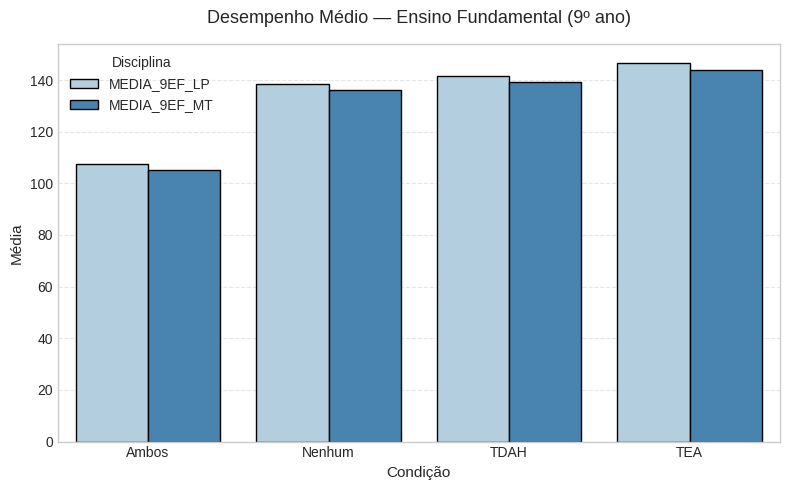

In [23]:
#Desempenho médio no Ensino Fundamental por condição (TDAH / TEA / Nenhum diagnóstico)

fund = df[["condicao", "MEDIA_9EF_LP", "MEDIA_9EF_MT"]].copy()

# Calcular médias por grupo
medias = (
    fund.groupby("condicao")[["MEDIA_9EF_LP", "MEDIA_9EF_MT"]]
    .mean()
    .reset_index()
)

# Criar paleta azul com 2 tons (uma para cada disciplina)
cores = sns.color_palette("Blues", n_colors=2)

# Gráfico
plt.figure(figsize=(8,5))
sns.barplot(
    data=medias.melt(id_vars="condicao", var_name="Disciplina", value_name="Média"),
    x="condicao",
    y="Média",
    hue="Disciplina",
    palette=cores,
    edgecolor="black"
)

plt.title("Desempenho Médio — Ensino Fundamental (9º ano)", fontsize=13, pad=15)
plt.xlabel("Condição", fontsize=11)
plt.ylabel("Média", fontsize=11)
plt.legend(title="Disciplina")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


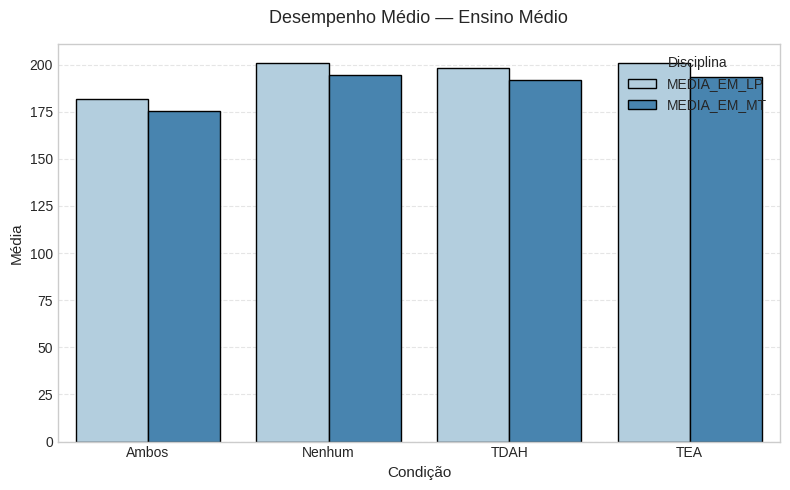

In [24]:
#Desempenho médio no Ensino Médio por condição (TDAH / TEA / Nenhum diagnóstico)

medio = df[["condicao", "MEDIA_EM_LP", "MEDIA_EM_MT"]].copy()

# Calcular médias por grupo
medias_medio = (
    medio.groupby("condicao")[["MEDIA_EM_LP", "MEDIA_EM_MT"]]
    .mean()
    .reset_index()
)

# Criar paleta azul com 2 tons (uma para cada disciplina)
cores = sns.color_palette("Blues", n_colors=2)

# Gráfico
plt.figure(figsize=(8,5))
sns.barplot(
    data=medias_medio.melt(id_vars="condicao", var_name="Disciplina", value_name="Média"),
    x="condicao",
    y="Média",
    hue="Disciplina",
    palette=cores,
    edgecolor="black"
)

plt.title("Desempenho Médio — Ensino Médio", fontsize=13, pad=15)
plt.xlabel("Condição", fontsize=11)
plt.ylabel("Média", fontsize=11)
plt.legend(title="Disciplina")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


/tmp/ipykernel_38/3311373316.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


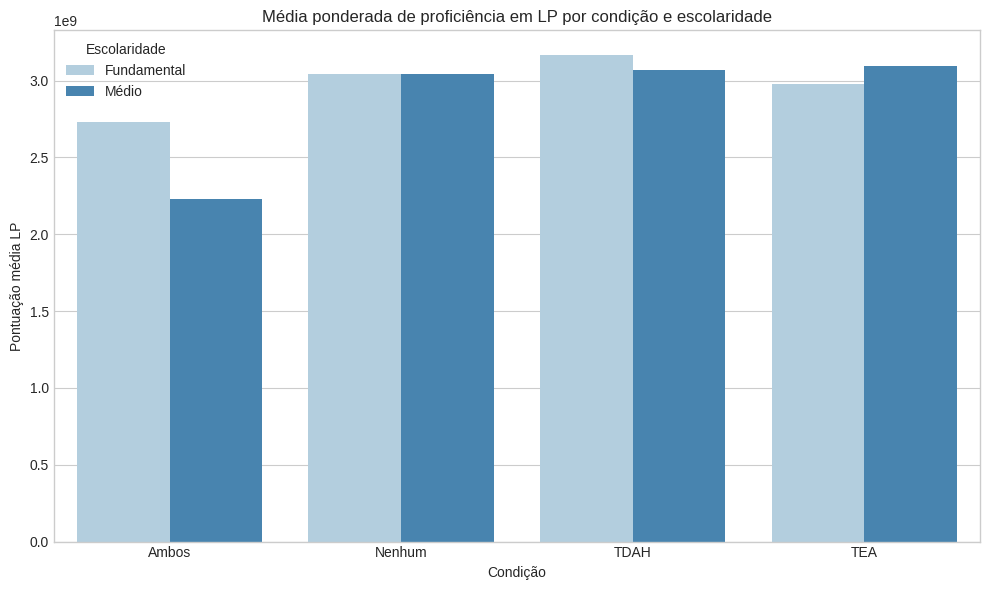

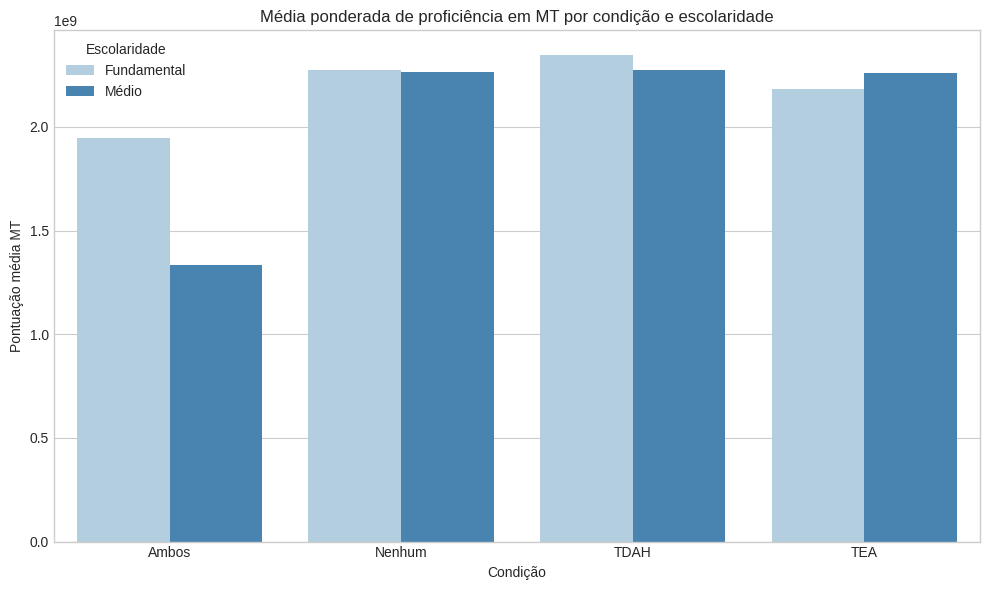

In [25]:
# Média ponderada de proficiência em MT por condição e escolaridade com paleta azul
df_plot = df[df["ESCOLARIDADE"].isin(["Fundamental", "Médio"])].copy()

# Função de média ponderada
def media_ponderada(g, var):
    return (g[var] * g["PESO_AMOSTRAL"]).sum() / g["PESO_AMOSTRAL"].sum()

# Calcular médias ponderadas de LP e MT por condição e escolaridade
desempenho = (
    df_plot.groupby(["ESCOLARIDADE", "condicao"])
    .apply(lambda g: pd.Series({
        "LP": media_ponderada(g, "PROFICIENCIA_LP"),
        "MT": media_ponderada(g, "PROFICIENCIA_MT")
    }))
    .reset_index()
)

# Criar paleta azul com 2 tons (uma para cada escolaridade)
cores = sns.color_palette("Blues", n_colors=2)

# Gráfico LP
plt.figure(figsize=(10,6))
sns.barplot(
    data=desempenho,
    x="condicao",
    y="LP",
    hue="ESCOLARIDADE",
    palette=cores
)
plt.title("Média ponderada de proficiência em LP por condição e escolaridade")
plt.ylabel("Pontuação média LP")
plt.xlabel("Condição")
plt.legend(title="Escolaridade")
plt.tight_layout()
plt.show()

# Gráfico MT
plt.figure(figsize=(10,6))
sns.barplot(
    data=desempenho,
    x="condicao",
    y="MT",
    hue="ESCOLARIDADE",
    palette=cores
)
plt.title("Média ponderada de proficiência em MT por condição e escolaridade")
plt.ylabel("Pontuação média MT")
plt.xlabel("Condição")
plt.legend(title="Escolaridade")
plt.tight_layout()
plt.show()


In [26]:
mapa_regioes = {
    'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte',
    'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',

    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste',
    'SE': 'Nordeste',

    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste',
    'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',

    'ES': 'Sudeste', 'MG': 'Sudeste',
    'RJ': 'Sudeste', 'SP': 'Sudeste',

    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

df['REGIAO'] = df['UF'].map(mapa_regioes)


--- CONFIRA OS NÚMEROS REAIS ABAIXO ---
         Região Faixa de Renda    Média LP    Média MT
0  Centro-Oeste    Muito Baixa  275.952000  266.148000
1  Centro-Oeste          Baixa  275.952000  266.148000
2  Centro-Oeste          Média  275.952000  266.148000
3  Centro-Oeste           Alta  275.952000  266.148000
4  Centro-Oeste     Muito Alta  275.952000  266.148000
5      Nordeste    Muito Baixa  270.088664  264.522122
6      Nordeste          Baixa  270.912213  265.508287
7      Nordeste          Média  271.154693  265.829626
8      Nordeste           Alta  270.316013  264.825657
9      Nordeste     Muito Alta  271.042917  265.686452


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

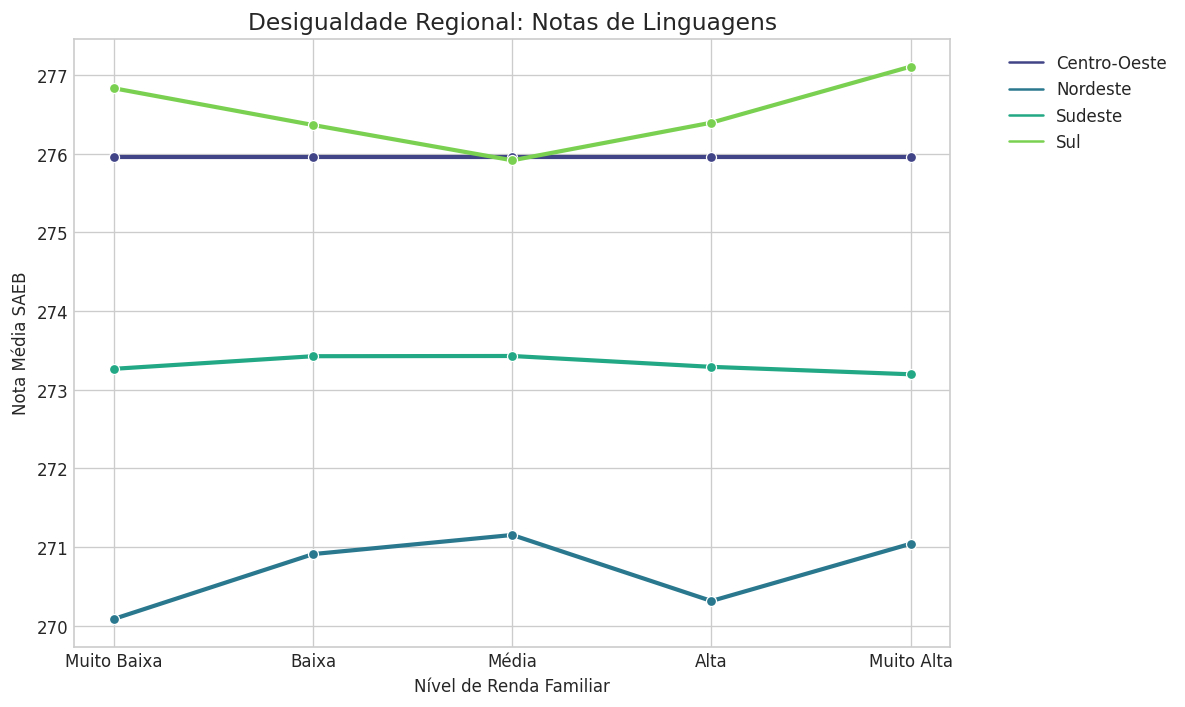

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

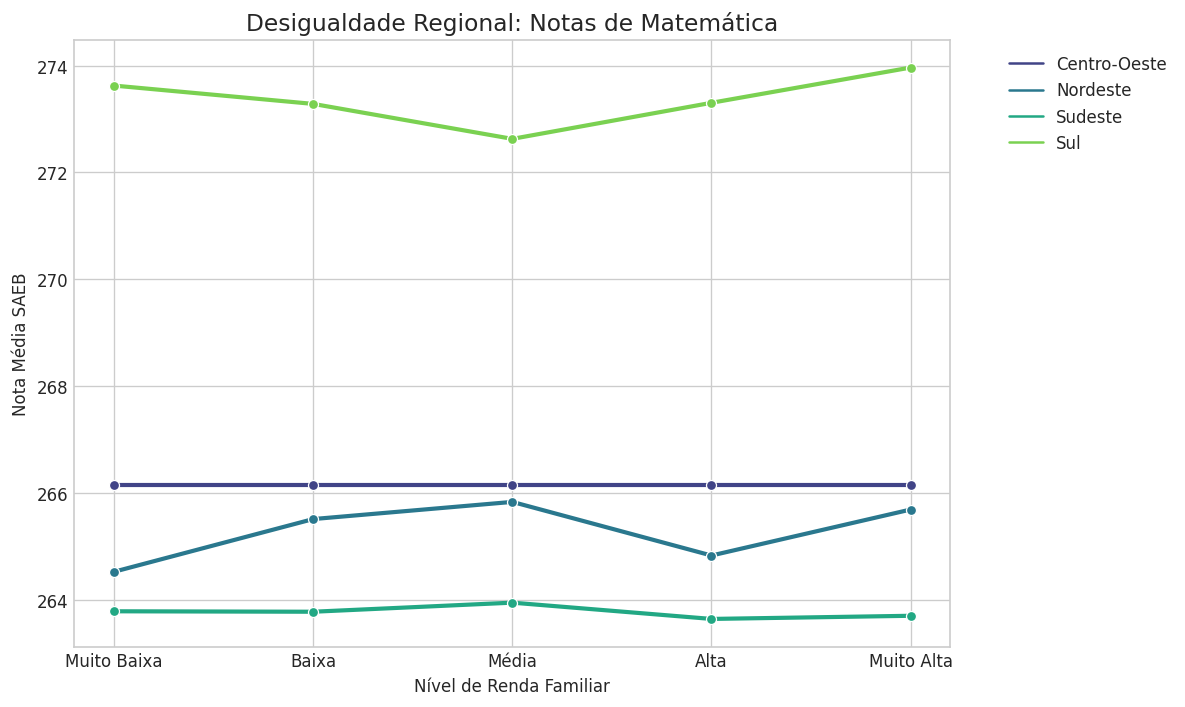

In [58]:
# 1. Preparação
df_analise = df_final.copy()

# Criar faixas de renda (Quintis)
df_analise['Faixa_Renda'] = pd.qcut(
    df_analise['RENDA'],
    q=5,
    labels=['Muito Baixa', 'Baixa', 'Média', 'Alta', 'Muito Alta']
)

# 2. Agrupamento e Visualização dos Números
analise_cruzada = (
    df_analise
    .groupby(['REGIAO', 'Faixa_Renda'], observed=False)[['NOTA_LP_FINAL', 'NOTA_MT_FINAL']]
    .mean()
    .reset_index()
)

# --- A CORREÇÃO ESTÁ AQUI: Renomear as colunas para bater com o gráfico ---
analise_cruzada.columns = ['Região', 'Faixa de Renda', 'Média LP', 'Média MT']

print("--- CONFIRA OS NÚMEROS REAIS ABAIXO ---")
print(analise_cruzada.head(10)) 

# 3. Gráficos com Zoom Automático
sns.set_style("whitegrid")

# --- Gráfico 1: Linguagens (LP) ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=analise_cruzada,
    x='Faixa de Renda',  # Agora existe essa coluna com espaço!
    y='Média LP',        # Agora existe essa coluna!
    hue='Região',
    marker='o',
    linewidth=2.5,
    palette='viridis'
)
plt.title('Desigualdade Regional: Notas de Linguagens', fontsize=14)
plt.ylabel('Nota Média SAEB')
plt.xlabel('Nível de Renda Familiar')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Gráfico 2: Matemática (MT) ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=analise_cruzada,
    x='Faixa de Renda',
    y='Média MT',
    hue='Região',
    marker='o',
    linewidth=2.5,
    palette='viridis'
)
plt.title('Desigualdade Regional: Notas de Matemática', fontsize=14)
plt.ylabel('Nota Média SAEB')
plt.xlabel('Nível de Renda Familiar')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

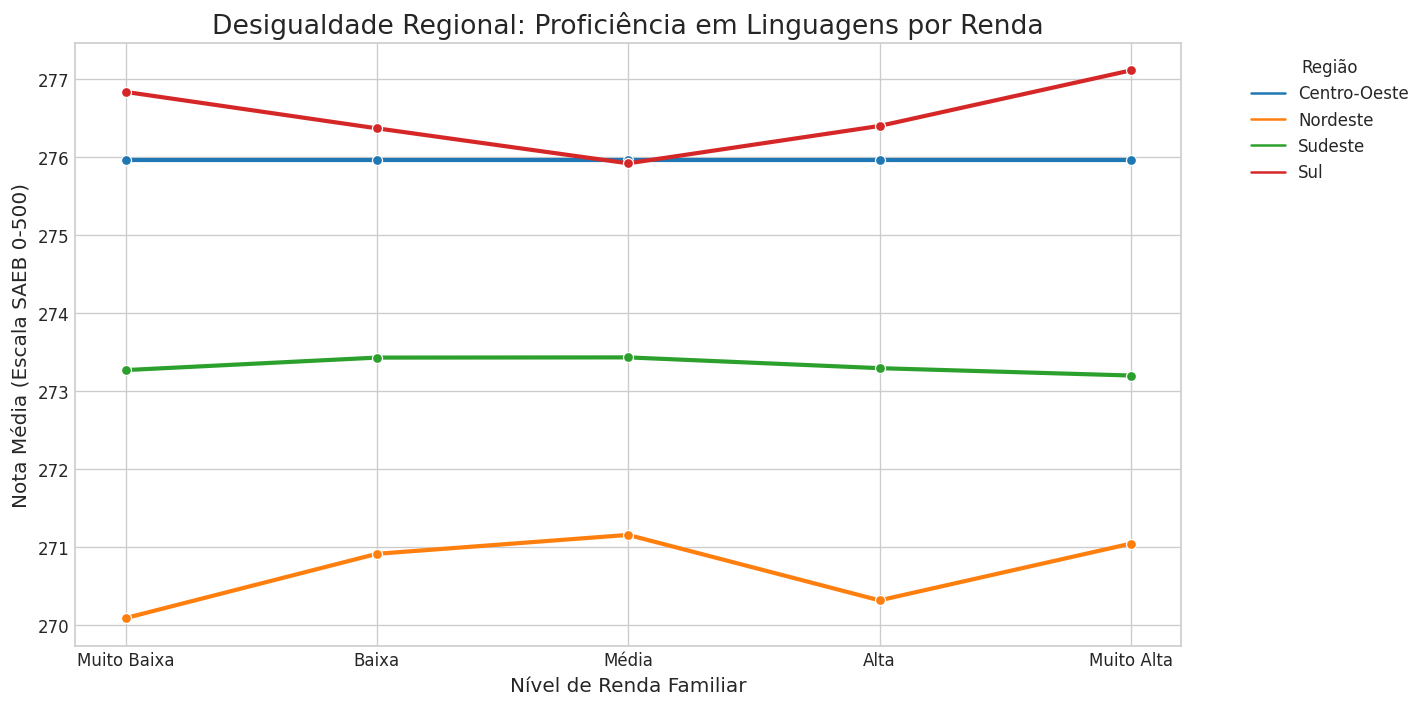

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

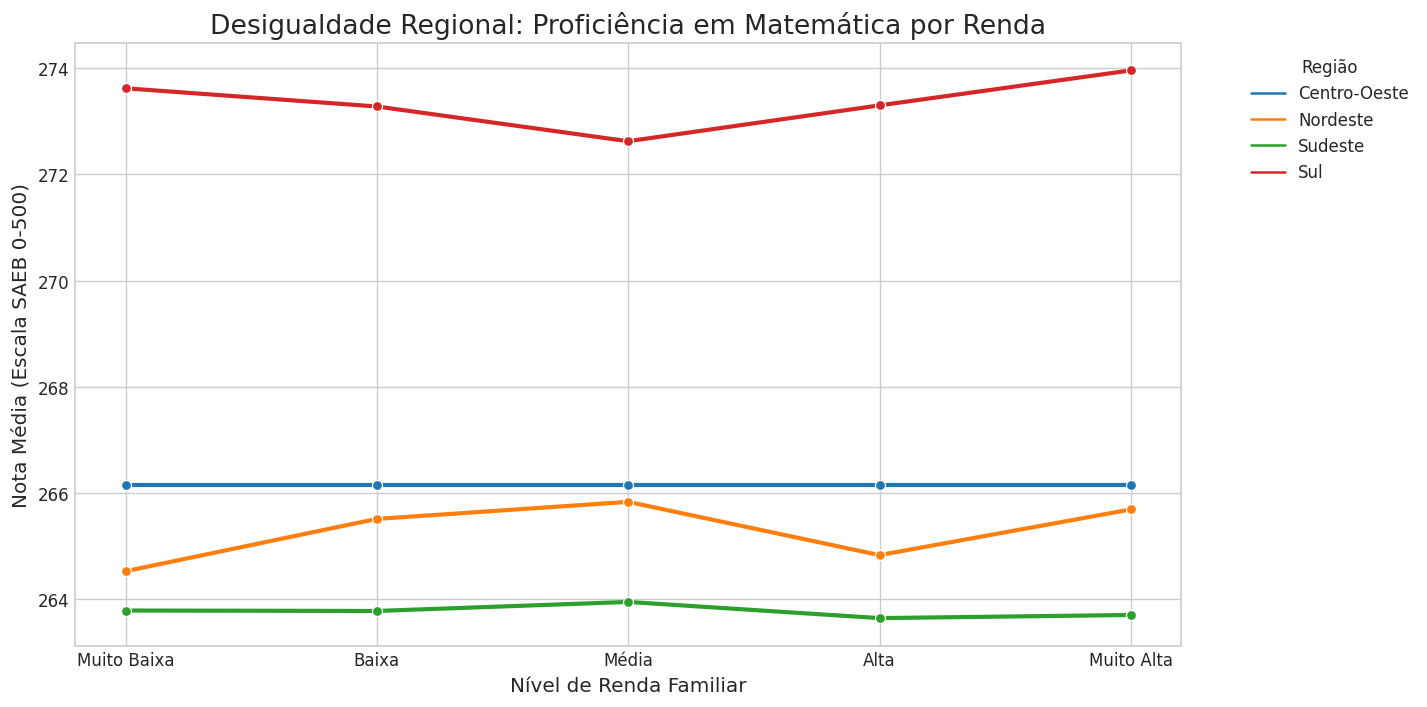

In [55]:
# --- CÓDIGO CORRIGIDO: GAP DE DESIGUALDADE (Região e Renda) ---

# 1. Preparação (USANDO O DF_FINAL CORRETO)
df_analise = df_final.copy()

# Criar faixa de renda (Quintis)
# Divide em 5 grupos: Muito Baixa até Muito Alta
df_analise['Faixa_Renda'] = pd.qcut(
    df_analise['RENDA'],
    q=5,
    labels=['Muito Baixa', 'Baixa', 'Média', 'Alta', 'Muito Alta']
)

# 2. Agrupamento por região e faixa de renda (USANDO AS NOTAS LIMPAS)
analise_cruzada = (
    df_analise
    .groupby(['REGIAO', 'Faixa_Renda'], observed=False)
    [['NOTA_LP_FINAL', 'NOTA_MT_FINAL']] # Colunas corrigidas
    .mean()
    .reset_index()
)

# 3. Configuração Visual
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# --- Gráfico de linhas para Linguagens (LP) ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=analise_cruzada,
    x='Faixa_Renda',
    y='NOTA_LP_FINAL', # Coluna corrigida
    hue='REGIAO',
    marker='o',
    palette='tab10',
    linewidth=2.5
)
plt.title('Desigualdade Regional: Proficiência em Linguagens por Renda', fontsize=16)
plt.xlabel('Nível de Renda Familiar', fontsize=12)
plt.ylabel('Nota Média (Escala SAEB 0-500)', fontsize=12)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Gráfico de linhas para Matemática (MT) ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=analise_cruzada,
    x='Faixa_Renda',
    y='NOTA_MT_FINAL', # Coluna corrigida
    hue='REGIAO',
    marker='o',
    palette='tab10',
    linewidth=2.5
)
plt.title('Desigualdade Regional: Proficiência em Matemática por Renda', fontsize=16)
plt.xlabel('Nível de Renda Familiar', fontsize=12)
plt.ylabel('Nota Média (Escala SAEB 0-500)', fontsize=12)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
# 1. Função para unificar as notas (Pega Ensino Médio; se for nulo/zero, pega Fundamental)
def unificar_notas(row, col_em, col_ef):
    nota_em = float(row[col_em]) if pd.notnull(row[col_em]) else 0.0
    nota_ef = float(row[col_ef]) if pd.notnull(row[col_ef]) else 0.0
    
    # Retorna a maior nota (assumindo que o aluno só tem uma das duas válida)
    return max(nota_em, nota_ef)

# 2. Criar as novas colunas limpas
# Usamos apply para processar linha a linha (pode demorar alguns segundos)
print("Unificando notas de Fundamental e Médio...")
df['NOTA_MT_FINAL'] = df.apply(lambda x: unificar_notas(x, 'MEDIA_EM_MT', 'MEDIA_9EF_MT'), axis=1)
df['NOTA_LP_FINAL'] = df.apply(lambda x: unificar_notas(x, 'MEDIA_EM_LP', 'MEDIA_9EF_LP'), axis=1)

# 3. Filtrar para análise (Remover Zeros e Notas Extremas que possam ser erro)
df_final = df[
    (df['NOTA_MT_FINAL'] > 100) & (df['NOTA_MT_FINAL'] < 500) &  # Filtra zeros e erros
    (df['NOTA_LP_FINAL'] > 100) & (df['NOTA_LP_FINAL'] < 500) &
    (df['condicao'].isin(['TEA', 'TDAH', 'Ambos', 'Nenhum']))
].copy()

# Garantir que RENDA e IDADE são numéricos
df_final['RENDA'] = pd.to_numeric(df_final['RENDA'], errors='coerce')
df_final['IDADE'] = pd.to_numeric(df_final['IDADE'], errors='coerce')

print(f"Base pronta para gráficos! Alunos válidos: {len(df_final)}")
print(df_final[['NOTA_MT_FINAL', 'NOTA_LP_FINAL']].describe())

Unificando notas de Fundamental e Médio...
Base pronta para gráficos! Alunos válidos: 148118
       NOTA_MT_FINAL  NOTA_LP_FINAL
count  148118.000000  148118.000000
mean      264.951013     273.247317
std        17.226664      16.810005
min       218.020000     202.110000
25%       255.350000     262.180000
50%       262.790000     274.970000
75%       272.270000     284.450000
max       363.000000     343.360000


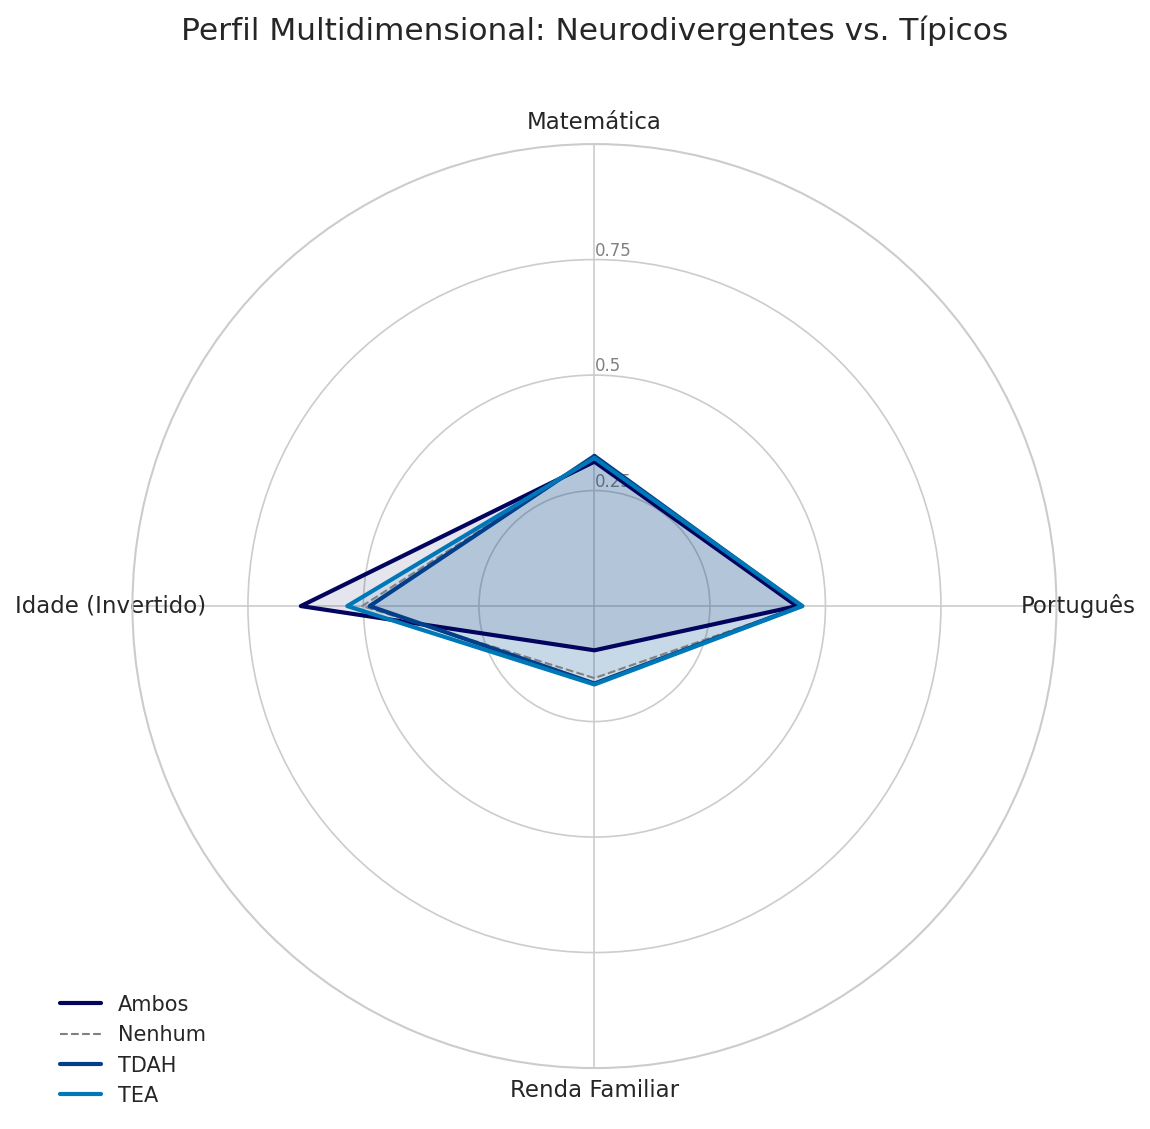

In [45]:
# 1. Selecionar variáveis CORRETAS (usando as notas limpas e Renda)
vars_radar = ['NOTA_MT_FINAL', 'NOTA_LP_FINAL', 'RENDA', 'IDADE']
labels_radar = ['Matemática', 'Português', 'Renda Familiar', 'Idade (Invertido)']

# 2. Preparar dataset
# Usamos df_final, que já tem as notas filtradas e limpas
df_radar = df_final[df_final['condicao'].isin(['TEA', 'TDAH', 'Ambos', 'Nenhum'])].copy()

# Remover linhas que tenham nulos nessas colunas específicas para não quebrar o cálculo
df_radar = df_radar.dropna(subset=vars_radar)

# 3. Normalizar (Colocar tudo na escala de 0 a 1 para o gráfico funcionar)
scaler = MinMaxScaler()
df_radar[vars_radar] = scaler.fit_transform(df_radar[vars_radar])

# Inverter idade (porque idade alta na escola é sinal de atraso, então invertemos para "ficar na ponta" quem está na idade certa)
df_radar['IDADE'] = 1 - df_radar['IDADE']

# 4. Calcular médias por condição
medias = df_radar.groupby('condicao')[vars_radar].mean().reset_index()

# 5. Configurar o gráfico Polar (Radar)
categories = labels_radar
N = len(categories)

# Ângulos para cada eixo
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Fechar o ciclo

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Configurar Eixos
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=11)
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.5", "0.75"], color="grey", size=8)
plt.ylim(0, 1)

# Dicionário de cores
cores = {'Nenhum': 'gray', 'TEA': '#0077b6', 'TDAH': '#023e8a', 'Ambos': '#03045e'}

# Plotar cada linha
for i, row in medias.iterrows():
    cond = row['condicao']
    
    
    values = row[vars_radar].values.flatten().tolist()
    values += values[:1] 
    
    cor_linha = cores.get(cond, 'black')
    
    # Se for "Nenhum", fazemos pontilhado (--). Se não, linha sólida (-)
    estilo_linha = 'dashed' if cond == 'Nenhum' else 'solid'
    largura = 1 if cond == 'Nenhum' else 2
    alpha_preenchimento = 0.05 if cond == 'Nenhum' else 0.1
    
    ax.plot(angles, values, linewidth=largura, linestyle=estilo_linha, label=cond, color=cor_linha)
    ax.fill(angles, values, color=cor_linha, alpha=alpha_preenchimento)

plt.title("Perfil Multidimensional: Neurodivergentes vs. Típicos", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

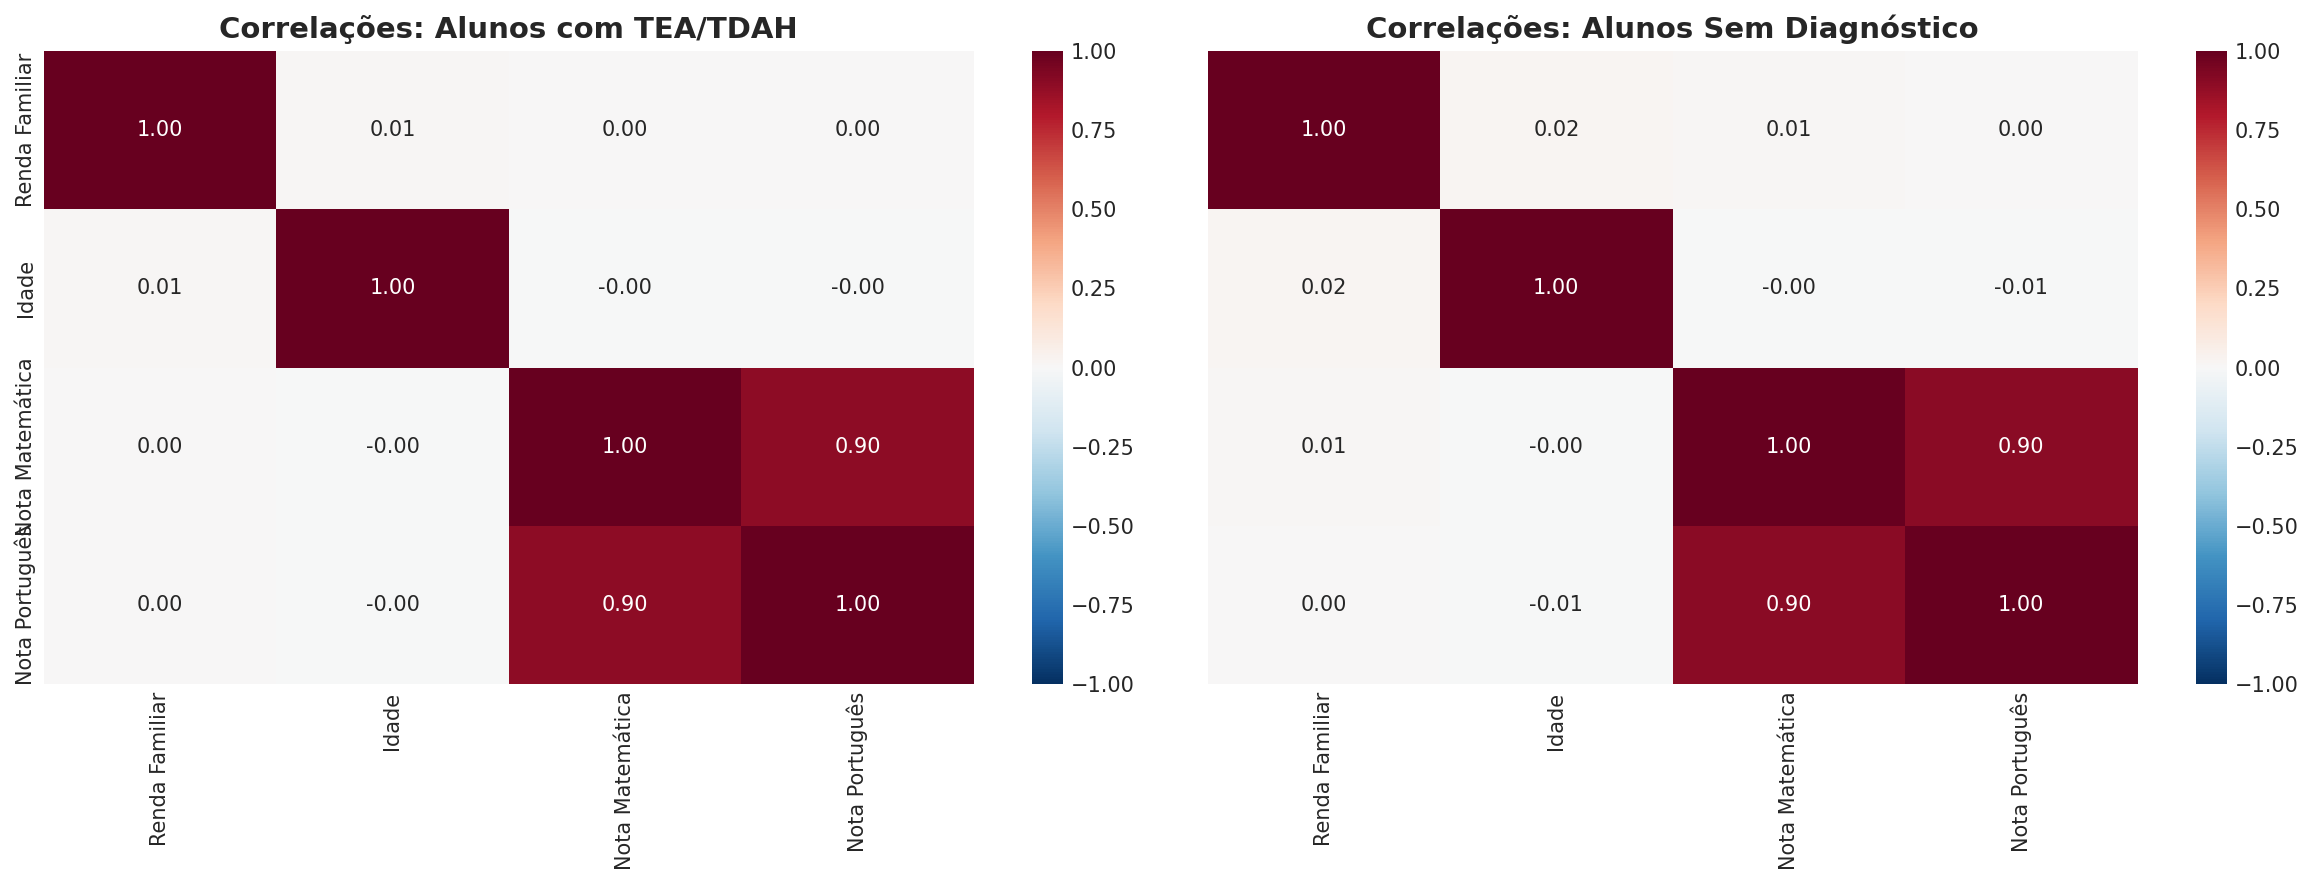

In [44]:
# --- MATRIZ DE CORRELAÇÃO CORRIGIDA ---
# Substitui o código antigo dos "Heatmaps"

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir as variáveis numéricas CORRETAS
# Trocamos INSE por RENDA e as notas SAEB pelas notas LIMPAS
colunas_corr = ['RENDA', 'IDADE', 'NOTA_MT_FINAL', 'NOTA_LP_FINAL']
labels_corr = ['Renda Familiar', 'Idade', 'Nota Matemática', 'Nota Português']

# 2. Separar os grupos usando df_final
# Grupo 1: Alunos com alguma condição
df_neuro = df_final[df_final['condicao'].isin(['TEA', 'TDAH', 'Ambos'])][colunas_corr].dropna()

# Grupo 2: Alunos sem diagnóstico (Nenhum)
# Pegamos uma amostra do mesmo tamanho para ser justo
df_tipico = df_final[df_final['condicao'] == 'Nenhum'][colunas_corr].dropna().sample(n=len(df_neuro), random_state=42)

# 3. Calcular as matrizes de correlação
corr_neuro = df_neuro.corr()
corr_tipico = df_tipico.corr()

# 4. Plotar os Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Heatmap - Neurodivergentes
sns.heatmap(corr_neuro, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, ax=axes[0],
            xticklabels=labels_corr, yticklabels=labels_corr)
axes[0].set_title('Correlações: Alunos com TEA/TDAH', fontsize=14, fontweight='bold')

# Heatmap - Sem Diagnóstico
sns.heatmap(corr_tipico, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, ax=axes[1],
            xticklabels=labels_corr, yticklabels=labels_corr)
axes[1].set_title('Correlações: Alunos Sem Diagnóstico', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


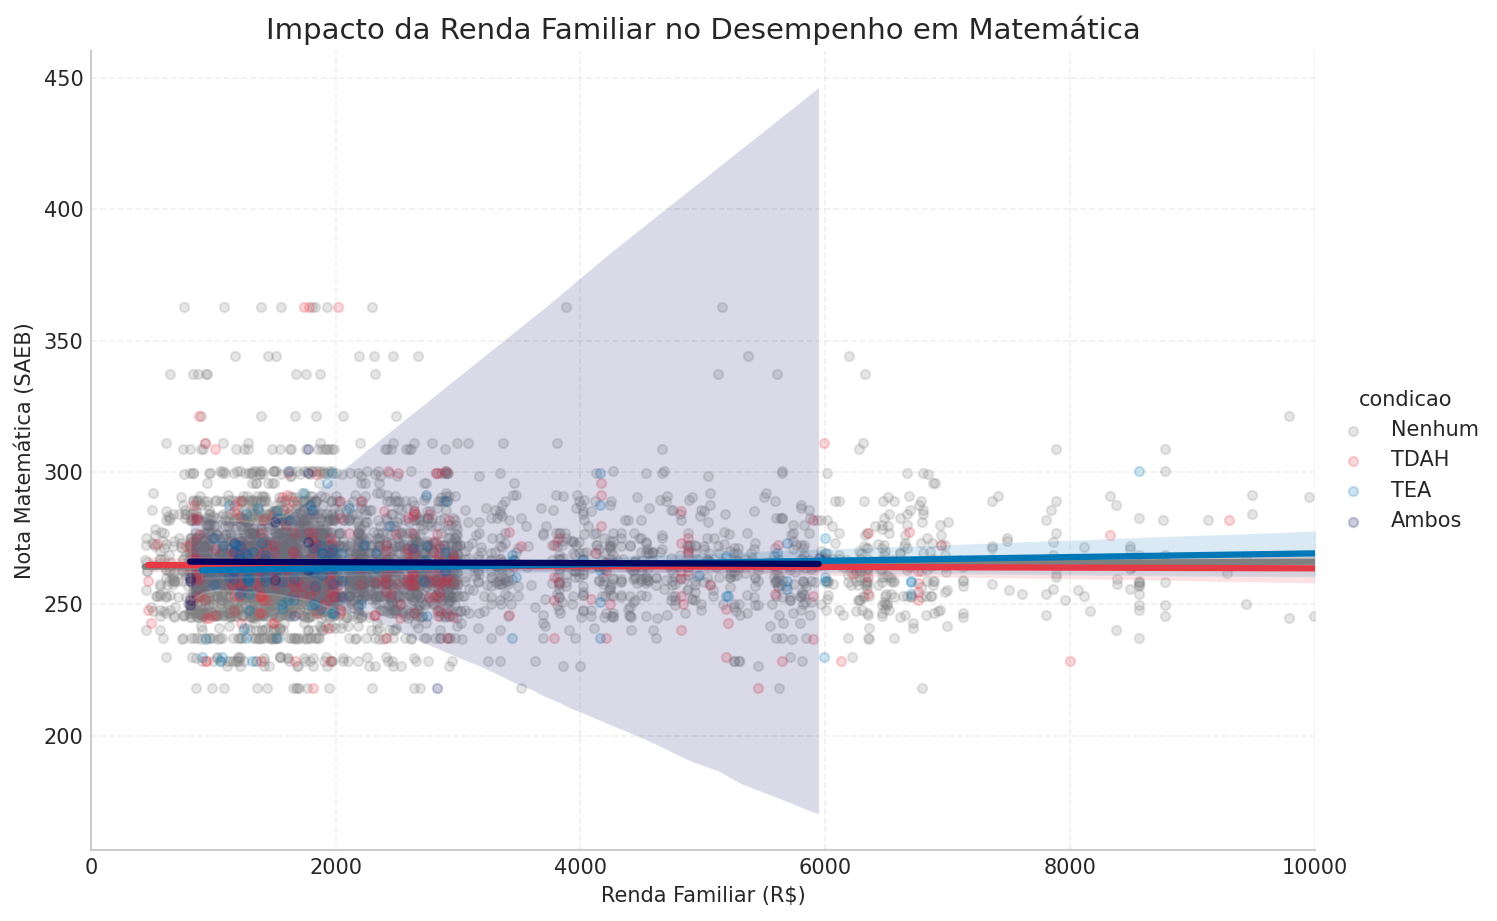

In [46]:
# --- PASSO 3: GRÁFICO DE REGRESSÃO CORRIGIDO ---
# Pegar amostra para o gráfico não ficar pesado
df_reg = df_final.sample(n=min(5000, len(df_final)), random_state=42)

# O próprio lmplot define o tamanho com height e aspect
sns.lmplot(
    data=df_reg,
    x="RENDA",         
    y="NOTA_MT_FINAL", 
    hue="condicao",
    palette={'Nenhum': 'gray', 'TEA': '#0077b6', 'TDAH': '#e63946', 'Ambos': '#03045e'},
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.2, 's': 20},
    line_kws={'linewidth': 3}
)

plt.title('Impacto da Renda Familiar no Desempenho em Matemática', fontsize=14)
plt.xlabel('Renda Familiar (R$)')
plt.ylabel('Nota Matemática (SAEB)')
plt.xlim(0, 10000) 
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

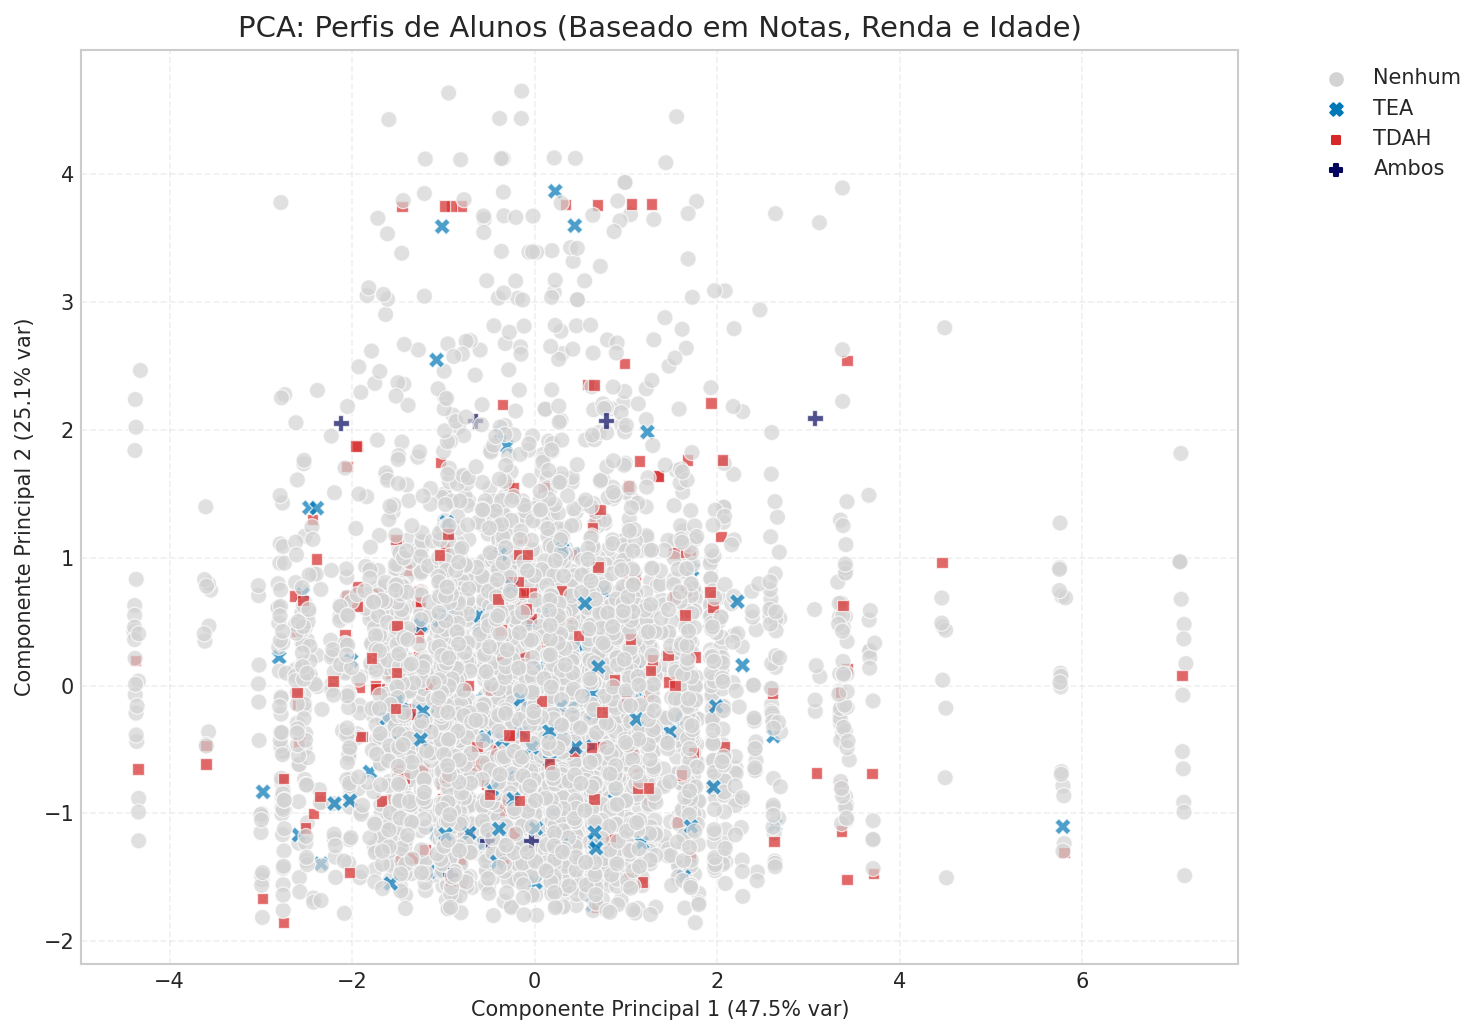

Peso das variáveis no Eixo X (PC1):
NOTA_LP_FINAL    0.707026
NOTA_MT_FINAL    0.706938
RENDA            0.006132
IDADE           -0.017768
dtype: float64


In [43]:
# 1. Selecionar features CORRETAS
features = ['NOTA_LP_FINAL', 'NOTA_MT_FINAL', 'RENDA', 'IDADE']

# 2. Preparar dados (usando df_final)
# Remover nulos nessas colunas específicas
df_pca = df_final.dropna(subset=features + ['condicao']).copy()

# Se a base for muito grande, pegamos uma amostra para o gráfico ficar legível
if len(df_pca) > 5000:
    df_pca = df_pca.sample(n=5000, random_state=42)

# 3. Padronizar os dados (Obrigatório para PCA)
x = StandardScaler().fit_transform(df_pca[features])

# 4. Aplicar PCA (Reduzir para 2 dimensões)
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)

# 5. Criar DataFrame para plotagem
pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
pca_df['Condição'] = df_pca['condicao'].values

# 6. Plotar
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Condição', 
    style='Condição',
    # Adicionamos a cor para "Ambos" que faltava antes
    palette={'Nenhum': 'lightgray', 'TEA': '#0077b6', 'TDAH': '#d62828', 'Ambos': '#03045e'},
    alpha=0.7,
    s=60
)

plt.title('PCA: Perfis de Alunos (Baseado em Notas, Renda e Idade)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretação dos Eixos (Para seu relatório)
print("Peso das variáveis no Eixo X (PC1):")
print(pd.Series(pca.components_[0], index=features).sort_values(ascending=False))

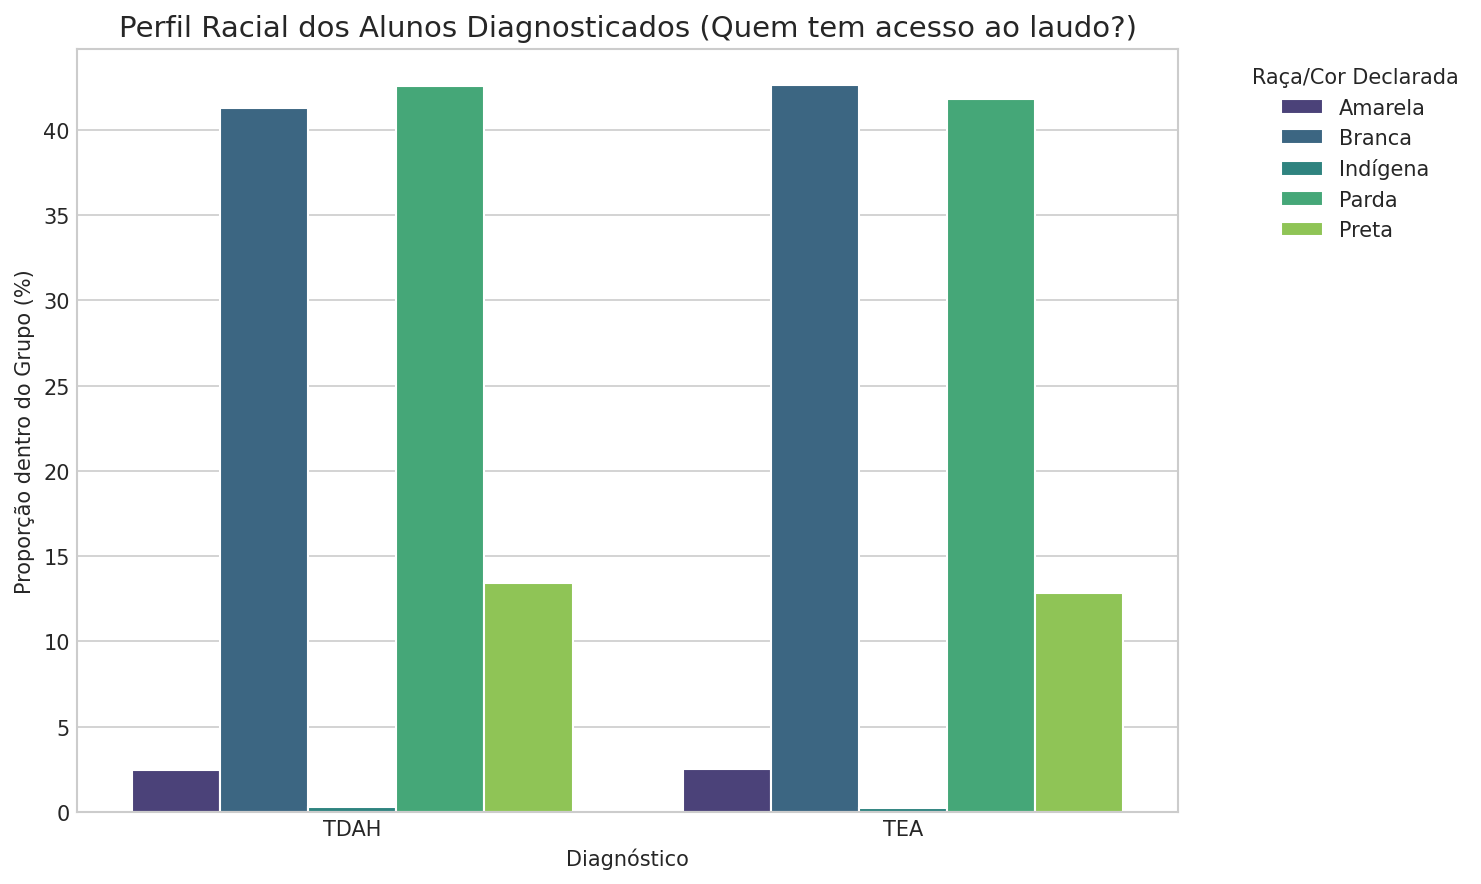

In [50]:
# Mapeamento SAEB
mapa_raca = {'A': 'Branca', 'B': 'Preta', 'C': 'Parda', 'D': 'Amarela', 'E': 'Indígena'}

# Filtrar e criar cópia usando df_final (para manter consistência com os filtros de idade/nota)
df_raca = df_final[df_final['condicao'].isin(['TEA', 'TDAH'])].copy()
df_raca['Raca'] = df_raca['TX_RESP_Q04'].map(mapa_raca)

# Remover nulos
df_raca = df_raca.dropna(subset=['Raca'])

# Contagem absoluta
props = (
    df_raca
    .groupby(['condicao', 'Raca'])
    .size()
    .reset_index(name='Contagem')
)

# Porcentagem dentro de cada condição
props['Porcentagem'] = (
    props
    .groupby('condicao')['Contagem']
    .transform(lambda x: 100 * x / x.sum())
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=props,
    x='condicao',
    y='Porcentagem',
    hue='Raca',
    palette='viridis' # Alterado para viridis para evitar erro se blue_palette não existir
)

blue_palette = ["#1f77b4", "#4fa3d1", "#9ecae1"]

plt.title('Perfil Racial dos Alunos Diagnosticados (Quem tem acesso ao laudo?)', fontsize=14)
plt.ylabel('Proporção dentro do Grupo (%)')
plt.xlabel('Diagnóstico')
plt.legend(title='Raça/Cor Declarada', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

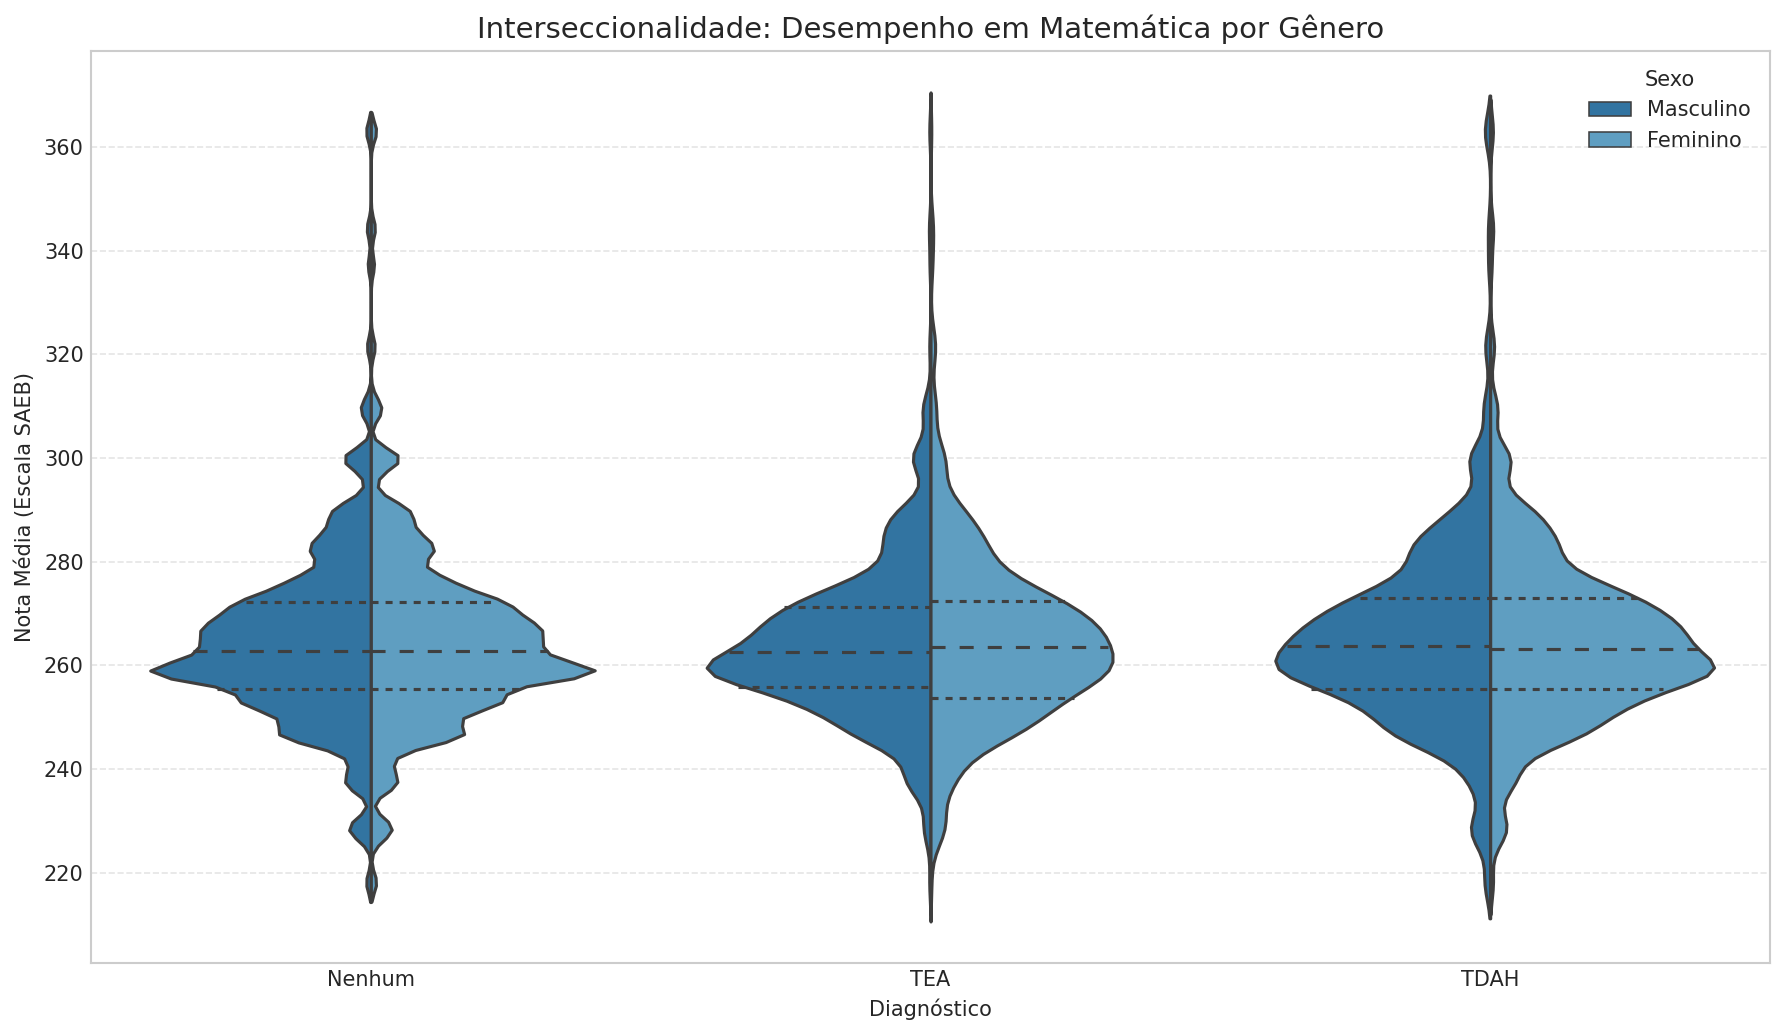

In [38]:
plt.figure(figsize=(12, 7))

# Preparar dados
df_violin = df_final[df_final['condicao'].isin(['Nenhum', 'TEA', 'TDAH'])].copy()
mapa_sexo = {'F': 'Feminino', 'M': 'Masculino'} # Ajustado para seus dados F/M
df_violin['Sexo_Label'] = df_violin['SEXO'].map(mapa_sexo)

# Plotar
sns.violinplot(
    data=df_violin, 
    x='condicao', 
    y='NOTA_MT_FINAL', # Usando a coluna nova!
    hue='Sexo_Label', 
    split=True, 
    inner='quartile',
    palette={'Masculino': '#1f77b4', 'Feminino': '#4fa3d1'},
    gap=0.1
)

plt.title('Interseccionalidade: Desempenho em Matemática por Gênero', fontsize=14)
plt.ylabel('Nota Média (Escala SAEB)')
plt.xlabel('Diagnóstico')
plt.legend(title='Sexo')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

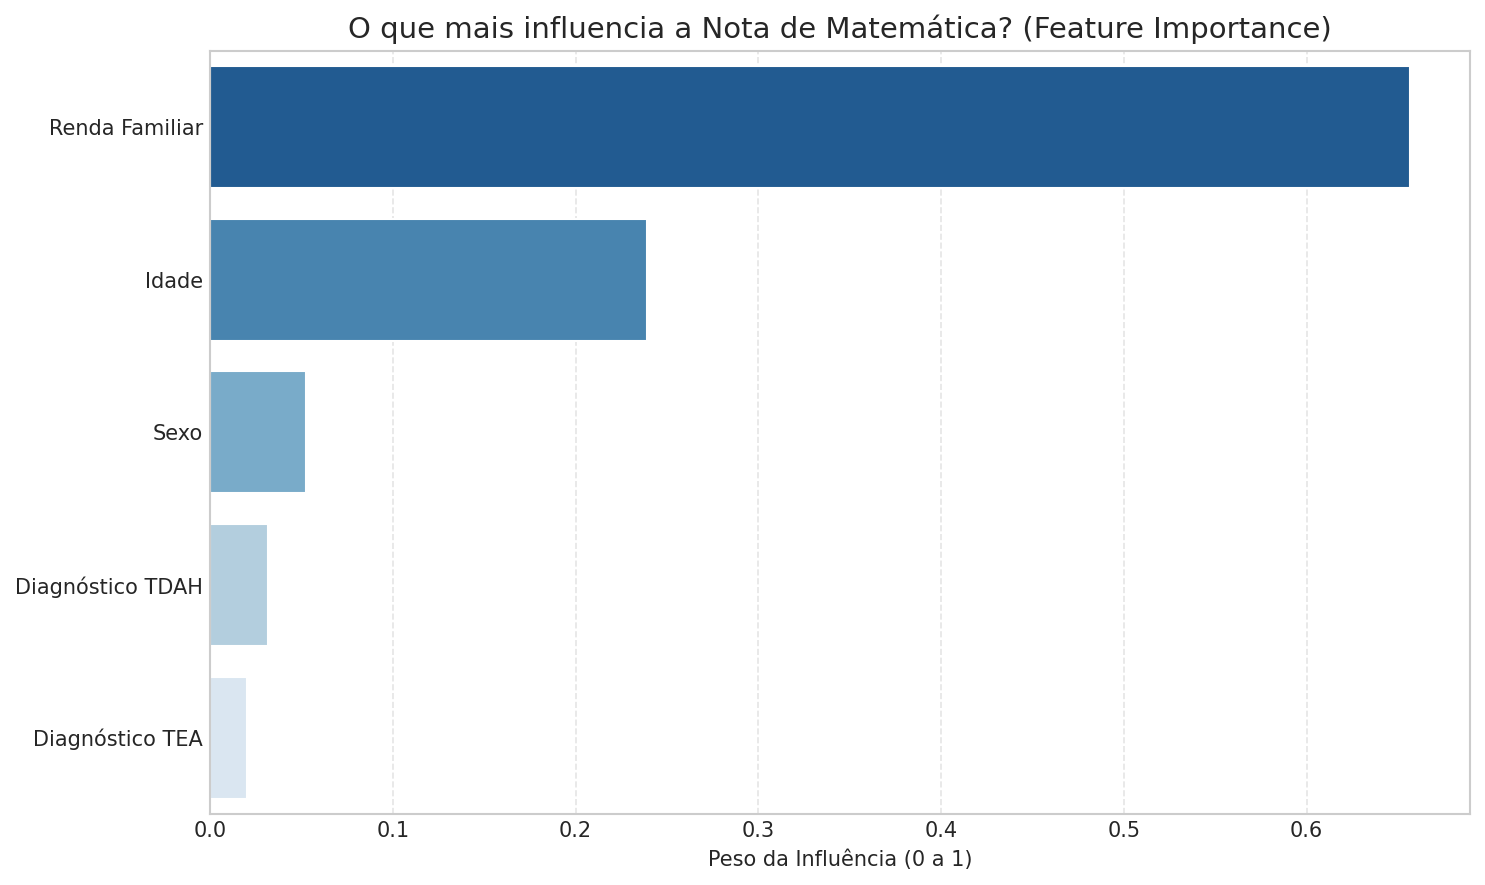

In [51]:
# GRÁFICO: FEATURE IMPORTANCE (RANDOM FOREST)

# 1. Definir features (variáveis explicativas) e target (nota)
# Usando as variáveis limpas e corretas do df_final
feats_model = ['RENDA', 'IDADE', 'SEXO', 'TEA_bin', 'TDAH_bin']
target_col = 'NOTA_MT_FINAL'

# 2. Preparar dados para o modelo
df_model = df_final.copy()

# Converter SEXO para números (0 e 1), pois o modelo matemático não aceita texto "F"/"M"
# Ajuste o dicionário abaixo conforme seus dados reais (se for 'F'/'M' ou 'Feminino'/'Masculino')
mapa_sexo_num = {'M': 0, 'F': 1, 'Masculino': 0, 'Feminino': 1}
df_model['SEXO_NUM'] = df_model['SEXO'].map(mapa_sexo_num)

# Atualizar a lista de colunas para usar o sexo numérico
feats_finais = ['RENDA', 'IDADE', 'SEXO_NUM', 'TEA_bin', 'TDAH_bin']

# Remover linhas que tenham nulos nessas colunas específicas
df_model = df_model.dropna(subset=feats_finais + [target_col])

# 3. Treinar o Modelo (Random Forest)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(df_model[feats_finais], df_model[target_col])

# 4. Extrair e Organizar a Importância das Variáveis
importances = pd.DataFrame({
    'Variável': ['Renda Familiar', 'Idade', 'Sexo', 'Diagnóstico TEA', 'Diagnóstico TDAH'],
    'Importância': rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

# 5. Plotar o Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importância', y='Variável', palette='Blues_r')
plt.title('O que mais influencia a Nota de Matemática? (Feature Importance)', fontsize=14)
plt.xlabel('Peso da Influência (0 a 1)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()